### Lec-1 Explore California Housing Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing(as_frame=True)
california_housing

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [13]:
df = california_housing['frame']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


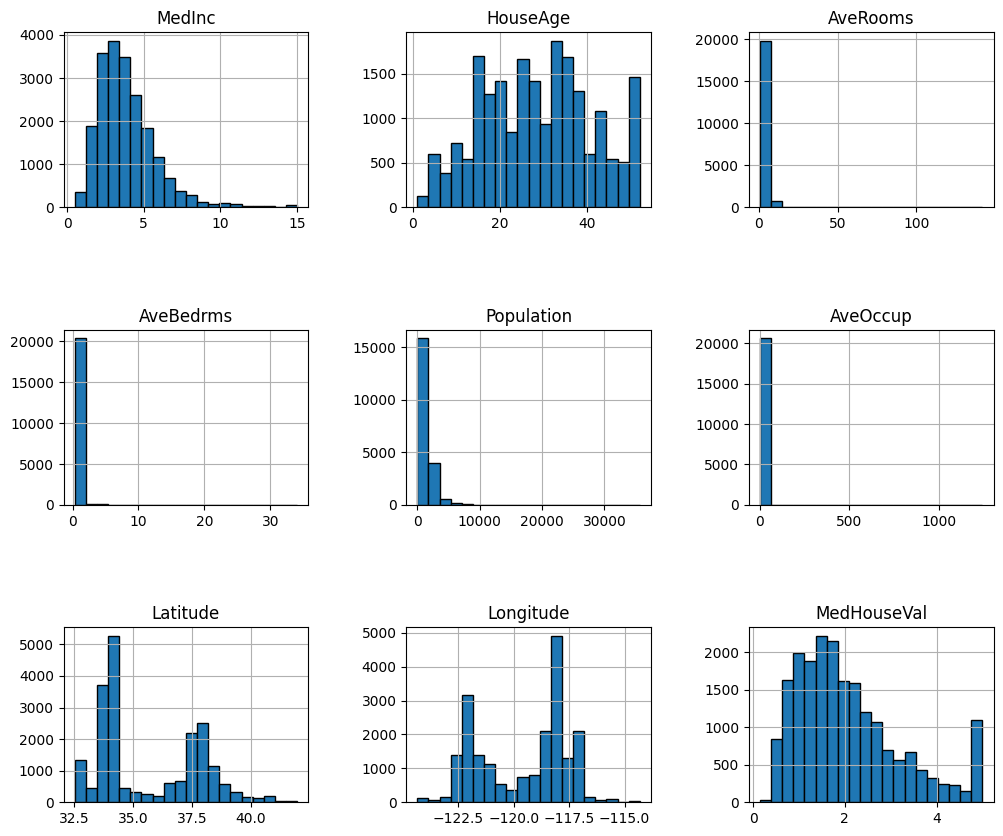

In [14]:
df.hist(figsize=(12,10), bins=20, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

In [15]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


---
### Lec-2 Linear Regression on California Housing

This lecture provides a comprehensive walkthrough of implementing and comparing various linear regression models for housing price prediction using the California Housing dataset. The process emphasizes using pipelines to maintain clean, scalable workflows.

#### Model Implementation Steps
1. Baseline and Normal Equation: Start with a baseline dummy regressor and a standard Linear Regression model utilizing the Normal Equation to establish initial performance metrics.
2. Iterative Optimization: Explore Stochastic Gradient Descent (SGD) for large-scale learning, focusing on convergence through parameter tuning like tolerance and early stopping.
3. Polynomial Regression: Address underfitting by incorporating non-linear features through polynomial transformations, utilizing validation curves to determine the optimal degree.
4. Regularization Techniques: Implement Ridge and Lasso regression to prevent overfitting. These models add penalty terms to the loss function:
    - Ridge Regression: Adds an L2 penalty, helping to stabilize weights.
    - Lasso Regression: Adds an L1 penalty, encouraging sparsity in the model.

#### Hyperparameter Tuning
To optimize model performance, the lecture employs:

- Grid Search CV: Systematically testing combinations of polynomial degrees and regularization strengths (alpha).
R- andomized Search CV: Efficiently sampling hyperparameter distributions for complex models like SGD with Elastic Net penalties.

#### Final Evaluation
Models are assessed using Mean Absolute Error (MAE) across training, development, and test sets. Comparisons reveal that Ridge Regression often yields the most balanced performance, effectively reducing both training and generalization errors compared to simpler linear counterparts.






In [19]:
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, RidgeCV, Ridge, SGDRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_predict, cross_validate, cross_val_score, ShuffleSplit
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline

In [20]:
np.random.seed(42)

In [21]:
cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)

In [22]:
features, labels = fetch_california_housing(as_frame=True, return_X_y=True)
train_x, test_x, train_y, test_y = train_test_split(features, labels, random_state=42)

In [23]:
linreg_pipeline = Pipeline([
    ("feature_scaling", StandardScaler()),
    ("lin_reg", LinearRegression())
])
linreg_cv = cross_validate(linreg_pipeline, train_x, train_y, cv=cv, scoring="neg_mean_absolute_error", return_train_score=True, return_estimator=True)

In [25]:
linreg_train_error = -1 * linreg_cv['train_score']
linreg_train_error

array([0.53432327, 0.52950337, 0.52972591, 0.53233173, 0.52827875,
       0.53088043, 0.52799365, 0.53377084, 0.5269963 , 0.53021738])

---
### Lec-3 Linear Regression Demonstration

This lecture demonstrates building a Linear Regression model using the scikit-learn library, focusing on the California Housing dataset. The workflow emphasizes best practices in machine learning, from preprocessing to model evaluation.

#### Model Workflow
1. Data Preparation: The data is loaded into feature matrices and label vectors. The process includes splitting the data into training and test sets to ensure unbiased evaluation.
2. Pipeline Construction: A scikit-learn pipeline is used to combine:
    - StandardScaler: Normalizes features to a uniform scale.
    - LinearRegression: Trains the model using the Normal Equation.
3. Evaluation Techniques: Performance is assessed using:
    - R-squared Score: Measures the coefficient of determination.
    - Cross-Validation: Uses ShuffleSplit to calculate robust scores across multiple folds, reporting both the mean and standard deviation of errors.
4. Diagnostic Analysis: Learning curves are plotted to identify common pitfalls like underfitting, where both training and test errors remain high even as more data is added.

#### Model Interpretation
The lecture concludes by examining the learned weight vector (coefficients) and intercept. Analyzing the model's coefficients across different cross-validation folds helps assess feature importance and detect the presence of outliers. Finally, visualizing predicted versus actual values reveals discrepancies, suggesting potential areas for iterative model improvement through feature engineering or constraint application.

---
### Lec-4 Baseline Model

This lecture explores establishing performance benchmarks for regression models using scikit-learn.

#### Core Approaches
- DummyRegressor: Provides simple baselines using strategies like mean, median, constant, or quantile predictions.
- Permutation Test Score: Evaluates models by shuffling target labels to test the null hypothesis that features and targets are independent.

#### Model Evaluation
1. Use cross-validation to assess performance.
2. Calculate errors using Negative Mean Absolute Error (converting to error by multiplying by -1).
3. Compare advanced models against these baselines to determine if performance gains are significant.

---
### Lec-5 SGDregressor Demonstration

This lecture explores the implementation of linear regression using the SGDRegressor class from scikit-learn. Unlike standard linear models, this approach leverages stochastic gradient descent to optimize parameters efficiently, making it suitable for large-scale datasets.

#### Key Concepts and Optimization
- Model Setup: The process involves creating a pipeline that integrates feature scaling—essential for gradient-based methods—with the regression model.
- Learning Rate Schedules: The lecture contrasts different strategies:
    1. Constant: Maintains a fixed learning rate throughout training.
    2. Adaptive: Adjusts the rate based on progress.
    3. Inverse Scaling: Gradually decreases the learning rate over time to improve convergence.

#### Stability and Tuning
- Hyperparameter Tuning: Validation curves are utilized to visualize how parameters like learning rate impact model performance on training versus test sets.
- Early Stopping: This technique helps prevent overfitting and saves computation by halting training when validation performance plateaus.
- Averaged SGD: Discussed as a method to improve parameter estimation stability, leading to more robust models for real-world regression tasks like housing price prediction.

---
### Lec-6 Demonstration: K-NN with California Housing Dataset

This lecture demonstrates applying the KNN algorithm for regression using the California Housing dataset to predict housing prices.

#### Key Steps
1. Preprocessing: Features are scaled using MinMaxScaler to ensure uniform distance calculations.
2. Model Pipeline: A pipeline integrates scaling and the KNN regressor.
3. Hyperparameter Tuning: The optimal number of neighbors (k) is identified through:
    - Manual cross-validation.
    - Automated GridSearchCV.
4. Advanced Features: Polynomial transformations are tested to improve predictive accuracy.

Performance is evaluated using metrics like MSE and RMSE.

---
### Lec-7 Decision Trees for Regression

This lecture explains applying Decision Trees for regression tasks using the California Housing dataset via scikit-learn.

#### Key Workflow
1. Pipeline Construction: Integrated feature scaling with StandardScaler and DecisionTreeRegressor.
2. Evaluation Metrics: Models were assessed using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R2 score.
3. Hyperparameter Tuning: Utilized GridSearchCV to optimize parameters like max_depth and min_samples_split.

#### Results
Optimization significantly improved performance, reducing MAE from 0.60 to 0.42 and increasing the R2 score from 0.51 to 0.68, demonstrating the effectiveness of tuning.

---
### Lec-8 Bagging & Random Forest Regressor on California HD

This lecture explores ensemble techniques to improve regression performance on the California Housing dataset.

#### Model Comparison
- Decision Tree: Acts as a baseline but suffers from severe overfitting, showing high variance.
- Bagging Regressor: Uses multiple decision trees to stabilize predictions and reduce test error.
- Random Forest: Further improves generalization by combining trees, achieving the lowest test error.

#### Optimization
1. Parameter Tuning: Employs RandomizedSearchCV to find optimal configurations.
2. Configuration: Adjusts hyper-parameters like the number of estimators and leaf nodes to minimize mean absolute error.


---
### Lec-9 AdaBoost & Gradient Boost Regressor on California Housing Dataset

This lecture explores boosting methods applied to the California Housing dataset to predict house prices:

#### Evaluated Models
- AdaBoost Regressor: Uses 50 estimators with a linear loss function.
- Gradient Boosting Regressor: Employs squared error loss with 100 estimators and a learning rate of 0.1.
- XGBoost Regressor: A regularized gradient boosting variant that provides improved generalization.

#### Key Findings
- Gradient Boosting and XGBoost outperformed AdaBoost.
- Default parameters offer a strong baseline, though hyperparameter tuning is recommended to further minimize error and enhance predictive accuracy on unseen data.





---
### Lec-10 MLP Regressor 

This lecture demonstrates using an MLPRegressor for housing price prediction via scikit-learn.

#### Workflow
1. Preprocessing: Data is scaled using StandardScaler.
2. Pipeline Construction: A pipeline integrates the scaler and MLPRegressor (32 hidden neurons).
3. Evaluation: Models are assessed using Mean Absolute Error (MAE) and Mean Absolute Percentage Error (MAPE).

#### Findings
- Performance: The model shows consistent results across training and test sets, indicating no significant overfitting.
- Limitations: High-value housing predictions (truncated at 5 million) remain challenging, leading to localized errors in the output.





---
---